## MULTI DATASET TOPIC MODELING

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
warnings.filterwarnings('ignore')

In [5]:
print('Loading processed dataset...')
PATH_CSV = "../../data/processed/multilingual_clean.csv"
df = pd.read_csv(PATH_CSV)
texts_lda = df['text_clean_classique'].fillna('').tolist()
texts_bert = df['text_clean_light'].fillna('').tolist()
sentiments = df['sentiment'].fillna('neutral').tolist()
tokens_lda = [text.split() for text in texts_lda]
print(f"Loaded {len(df)} rows")

Loading processed dataset...
Loaded 4500 rows


In [6]:
dictionary = corpora.Dictionary(tokens_lda)
dictionary.filter_extremes(no_below=5, no_above=0.8)
corpus = [dictionary.doc2bow(text) for text in tokens_lda]
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=8, random_state=42, passes=10, alpha='auto', per_word_topics=True)
print('LDA trained')

LDA trained


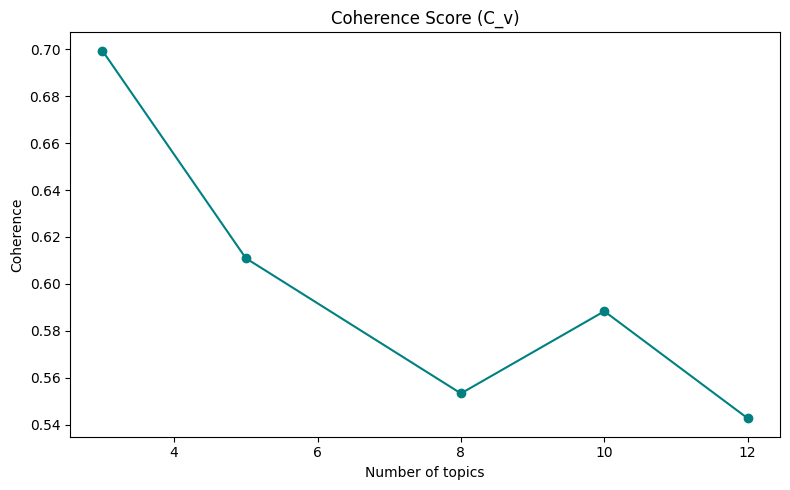


⚠ No k meets 90% threshold. Selected k=5 (minimum >= 5)

COHERENCE SCORES BY K:
k     Coherence       Status              
----------------------------------------
3     0.6994          ✗ Rejected          
5     0.6109          ✓ Selected          
8     0.5533          ✗ Rejected          
10    0.5883          ✗ Rejected          
12    0.5427          ✗ Rejected          

LDA Model trained with 5 topics

Topic 0: 0.024*"mzyan" + 0.023*"bzaf" + 0.019*"في" + 0.018*"b" + 0.018*"l" + 0.018*"machy" + 0.012*"lkn" + 0.012*"wa"
Topic 1: 0.015*"baby" + 0.011*"one" + 0.010*"like" + 0.010*"would" + 0.009*"get" + 0.009*"use" + 0.007*"month" + 0.007*"really"
Topic 2: 0.046*"le" + 0.042*"pa" + 0.038*"de" + 0.027*"la" + 0.025*"est" + 0.023*"et" + 0.022*"qualité" + 0.020*"très"
Topic 3: 0.061*"لا" + 0.029*"بشكل" + 0.023*"جيد" + 0.018*"يعمل" + 0.018*"في" + 0.016*"من" + 0.015*"ولكن" + 0.014*"شيء"
Topic 4: 0.031*"من" + 0.028*"على" + 0.025*"الجودة" + 0.023*"ليس" + 0.023*"bon" + 0.022*"ولكن" + 0.019*

In [12]:
k_values = [3, 5, 8, 10, 12]
coherence_scores = []
for k in k_values:
    lda_temp = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=10, alpha='auto')
    cm = CoherenceModel(model=lda_temp, texts=tokens_lda, dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())

plt.figure(figsize=(8, 5))
plt.plot(k_values, coherence_scores, marker='o', linestyle='-', color='teal')
plt.title('Coherence Score (C_v)')
plt.xlabel('Number of topics')
plt.ylabel('Coherence')
plt.tight_layout()
plt.show()

# =============================================================================
# Find optimal k: Good coherence + reasonable number of topics
# =============================================================================
min_topics = 5  # Minimum topics for meaningful analysis
max_coherence = max(coherence_scores)
coherence_threshold = max_coherence * 0.90  # Accept 90% of best coherence

# Filter k values that meet threshold AND have reasonable number
candidates = [
    (k, score) for k, score in zip(k_values, coherence_scores)
    if k >= min_topics and score >= coherence_threshold
]

if candidates:
    # Among candidates, choose the one with highest coherence
    best_k, best_coherence = max(candidates, key=lambda x: x[1])
    print(f"\n✓ OPTIMAL K SELECTION:")
    print(f"{'Criterion':<30} {'Value':<15}")
    print("-" * 45)
    print(f"{'Max coherence score':<30} {max_coherence:<15.4f}")
    print(f"{'Coherence threshold (90%)':<30} {coherence_threshold:<15.4f}")
    print(f"{'Minimum topics required':<30} {min_topics:<15}")
    print(f"{'Candidate k values':<30} {[k for k,_ in candidates]}")
    print(f"{'BEST K SELECTED':<30} {best_k:<15}")
    print(f"{'Coherence score':<30} {best_coherence:<15.4f}\n")
else:
    # If no candidates meet threshold, relax constraint
    best_k = max([(k, score) for k, score in zip(k_values, coherence_scores) if k >= min_topics], 
                 key=lambda x: x[1])[0]
    print(f"\n⚠ No k meets 90% threshold. Selected k={best_k} (minimum >= {min_topics})\n")

print(f"COHERENCE SCORES BY K:")
print(f"{'k':<5} {'Coherence':<15} {'Status':<20}")
print("-" * 40)
for k, score in zip(k_values, coherence_scores):
    status = "✓ Selected" if k == best_k else "✓ Candidate" if k >= min_topics and score >= coherence_threshold else "✗ Rejected"
    print(f"{k:<5} {score:<15.4f} {status:<20}")

lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_k, random_state=42, passes=15, alpha='auto')
print(f"\nLDA Model trained with {best_k} topics\n")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx}: {topic}")

In [8]:
print('Running BERTopic...')
bertopic_model = BERTopic(language='multilingual', nr_topics=best_k, verbose=True)
topics, probs = bertopic_model.fit_transform(texts_bert)
df_topics_bert = bertopic_model.get_topic_info()
print(df_topics_bert.head(best_k))

2026-05-11 02:42:52,719 - BERTopic - Embedding - Transforming documents to embeddings.


Running BERTopic...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/141 [00:00<?, ?it/s]

2026-05-11 02:44:45,939 - BERTopic - Embedding - Completed ✓
2026-05-11 02:44:45,942 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-11 02:45:27,489 - BERTopic - Dimensionality - Completed ✓
2026-05-11 02:45:27,506 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-11 02:45:27,758 - BERTopic - Cluster - Completed ✓
2026-05-11 02:45:27,760 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-11 02:45:27,929 - BERTopic - Representation - Completed ✓
2026-05-11 02:45:27,929 - BERTopic - Topic reduction - Reducing number of topics
2026-05-11 02:45:27,968 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-11 02:45:28,069 - BERTopic - Representation - Completed ✓
2026-05-11 02:45:28,069 - BERTopic - Topic reduction - Reduced number of topics from 165 to 3


   Topic  Count                    Name  \
0     -1    867        -1_the_it_to_and   
1      0   3558         0_the_it_to_and   
2      1     75  1_بشكل_لا_ولكن_android   

                                      Representation  \
0    [the, it, to, and, is, of, this, in, for, that]   
1    [the, it, to, and, is, this, of, for, that, in]   
2  [بشكل, لا, ولكن, android, يعمل, يوتيوب, من, ول...   

                                 Representative_Docs  
0  [first, if you're super-picky about your furni...  
1  [update: i bought this stroller and originally...  
2  [أداة جيدة بشكل عام، ولكن يوتيوب خطأ ويحتاج إل...  


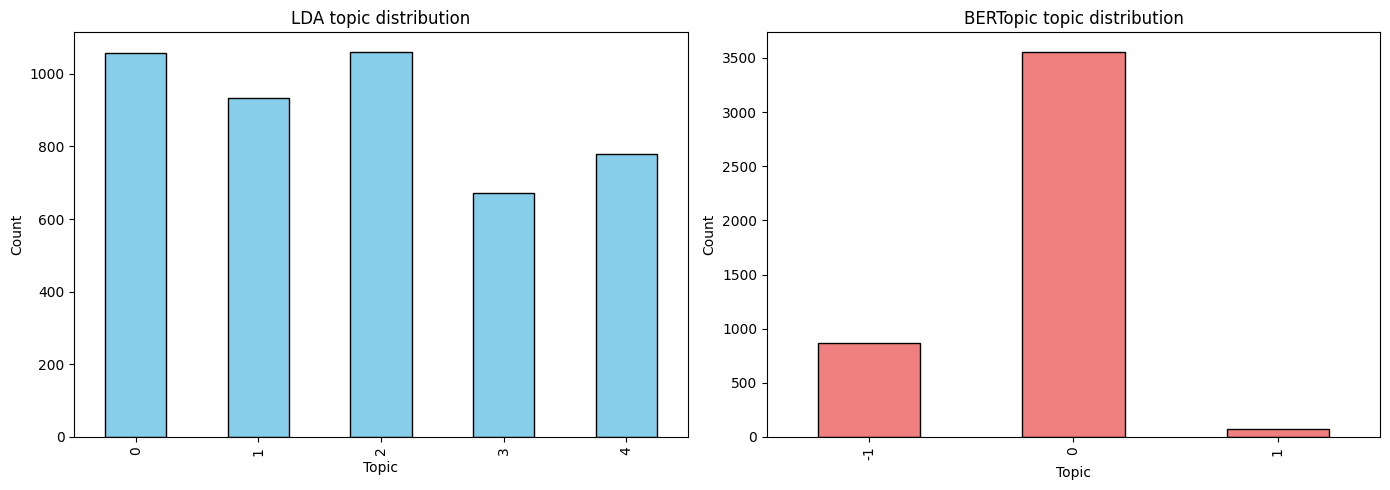


BERTOPIC ANALYSIS

Topics found: 3
Documents assigned to topics: 3633
Outlier documents (topic -1): 867
Outlier percentage: 19.3%

Generating BERTopic visualization...
⚠ Automatic visualization failed: ValueError

Generating custom BERTopic visualization instead...


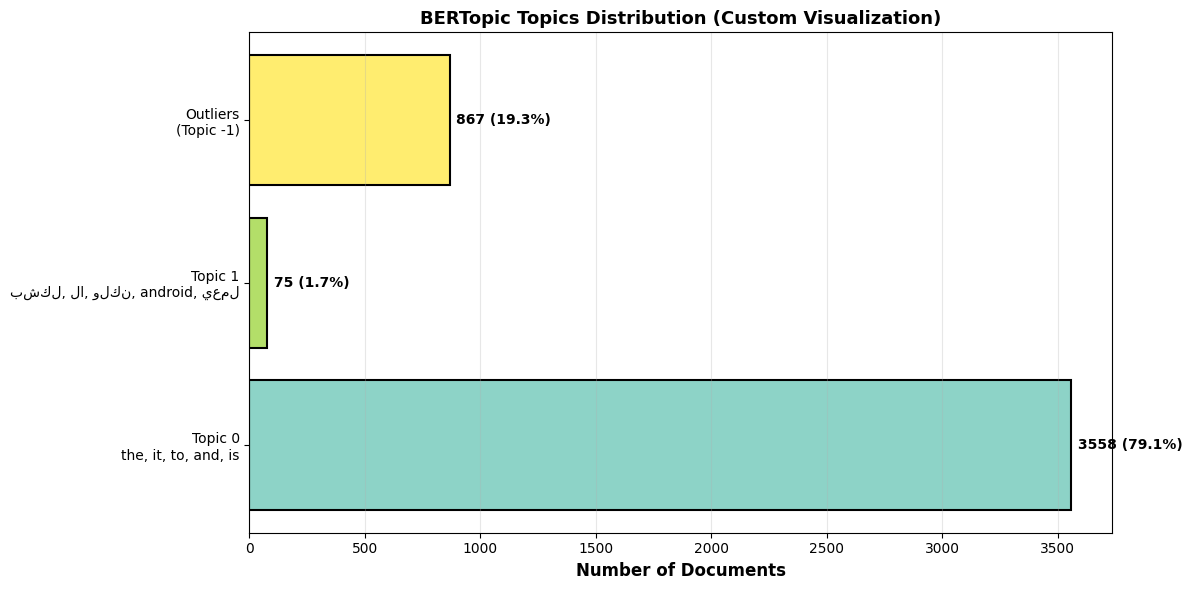


✓ Custom visualization generated successfully!

Topic Information:
   Topic  Count                    Name  \
0     -1    867        -1_the_it_to_and   
1      0   3558         0_the_it_to_and   
2      1     75  1_بشكل_لا_ولكن_android   

                                      Representation  \
0    [the, it, to, and, is, of, this, in, for, that]   
1    [the, it, to, and, is, this, of, for, that, in]   
2  [بشكل, لا, ولكن, android, يعمل, يوتيوب, من, ول...   

                                 Representative_Docs  
0  [first, if you're super-picky about your furni...  
1  [update: i bought this stroller and originally...  
2  [أداة جيدة بشكل عام، ولكن يوتيوب خطأ ويحتاج إل...  


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LDA topic distribution
lda_topics = [max(lda_model.get_document_topics(doc), key=lambda x: x[1])[0] for doc in corpus]
pd.Series(lda_topics).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('LDA topic distribution')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Count')

# BERTopic topic distribution
pd.Series(topics).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('BERTopic topic distribution')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# =============================================================================
# BERTopic Visualization with Error Handling & Fallback
# =============================================================================
print("\n" + "="*60)
print("BERTOPIC ANALYSIS")
print("="*60)

# Check BERTopic model state
topics_array = np.array(topics)
n_topics_found = len(set(topics_array))
n_outliers = (topics_array == -1).sum()
n_valid = len(topics_array) - n_outliers

print(f"\nTopics found: {n_topics_found}")
print(f"Documents assigned to topics: {n_valid}")
print(f"Outlier documents (topic -1): {n_outliers}")
print(f"Outlier percentage: {(n_outliers / len(topics_array) * 100):.1f}%")

# Try automatic visualization
if n_topics_found > 1 and n_valid > 0:
    try:
        print("\nGenerating BERTopic visualization...")
        bertopic_model.visualize_topics()
    except (ValueError, Exception) as e:
        print(f"⚠ Automatic visualization failed: {type(e).__name__}")
        print("\nGenerating custom BERTopic visualization instead...")
        
        # Custom visualization
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Get top words per topic
        topics_info = bertopic_model.get_topic_info()
        valid_topics = [t for t in topics_info['Topic'].unique() if t >= 0]
        
        topic_labels = []
        topic_counts = []
        
        for topic_id in sorted(valid_topics):
            topic_words = bertopic_model.get_topic(topic_id)
            if topic_words:
                top_words = ', '.join([word for word, _ in topic_words[:5]])
                topic_labels.append(f"Topic {topic_id}\n{top_words}")
            count = (topics_array == topic_id).sum()
            topic_counts.append(count)
        
        # Add outliers
        topic_labels.append("Outliers\n(Topic -1)")
        topic_counts.append(n_outliers)
        
        # Plot
        colors = plt.cm.Set3(np.linspace(0, 1, len(topic_labels)))
        bars = ax.barh(range(len(topic_labels)), topic_counts, color=colors, edgecolor='black', linewidth=1.5)
        
        # Add value labels
        for i, (bar, count) in enumerate(zip(bars, topic_counts)):
            pct = (count / len(topics_array)) * 100
            ax.text(count + 30, i, f'{count} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
        
        ax.set_yticks(range(len(topic_labels)))
        ax.set_yticklabels(topic_labels, fontsize=10)
        ax.set_xlabel('Number of Documents', fontsize=12, fontweight='bold')
        ax.set_title('BERTopic Topics Distribution (Custom Visualization)', fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Custom visualization generated successfully!")
else:
    print(f"\n⚠ Not enough valid topics ({n_topics_found}) for visualization")

print("\nTopic Information:")
print(df_topics_bert.head(best_k))

In [ ]:
comparison_table = pd.DataFrame({
    'Criterion': ['Type', 'Semantic', 'Context', 'Speed', 'Interpretability', 'Avg coherence'],
    'LDA': ['Word frequency', 'Low', 'None', 'Fast', 'High', f"{np.mean(coherence_scores):.3f}"],
    'BERTopic': ['Embeddings', 'High', 'High', 'Slower', 'Medium', 'Not measured']
})
print(comparison_table.to_markdown(index=False))

| Criterion        | LDA            | BERTopic     |
|:-----------------|:---------------|:-------------|
| Type             | Word frequency | Embeddings   |
| Semantic         | Low            | High         |
| Context          | None           | High         |
| Speed            | Fast           | Slower       |
| Interpretability | High           | Medium       |
| Avg coherence    | 0.616          | Not measured |


In [ ]:
df_analysis = df.copy()
df_analysis['lda_topic'] = lda_topics
df_analysis['bert_topic'] = topics
topic_names_lda = {
    i: ' '.join([w for w, _ in lda_model.show_topic(i, topn=5)])
    for i in range(lda_model.num_topics)
}
df_analysis['lda_topic_name'] = df_analysis['lda_topic'].map(topic_names_lda)
lda_sent = df_analysis.groupby('lda_topic_name')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)
bert_sent = df_analysis.groupby('bert_topic')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)
print((lda_sent * 100).round(1).to_markdown())
print((bert_sent * 100).round(1).to_markdown())

| lda_topic_name                              |   negative |   neutral |   positive |
|:--------------------------------------------|-----------:|----------:|-----------:|
| excellent dargent perte عجبني زوين          |       23.1 |       0   |       76.9 |
| money value great qualité moyen             |        0   |      49.3 |       50.7 |
| très الفلوس ضياع qualité rapport            |       50.4 |      23.9 |       25.8 |
| waste money recommended experience terrible |      100   |       0   |        0   |
| عادي مقبولة ديالو الجودة بيه                |       47   |      53   |        0   |
|   bert_topic |   negative |   neutral |   positive |
|-------------:|-----------:|----------:|-----------:|
|            0 |        0   |      49.8 |       50.2 |
|            1 |      100   |       0   |        0   |
|            2 |       49.7 |       0   |       50.3 |
|            3 |      100   |       0   |        0   |
|            4 |        0   |       0   |      100   |


In [ ]:
os.makedirs("../../outputs/results/", exist_ok=True)
os.makedirs("../../outputs/models/", exist_ok=True)
if 'review_id' not in df_analysis.columns:
    df_analysis = df_analysis.reset_index().rename(columns={'index': 'review_id'})
df_analysis[['review_id', 'lda_topic', 'lda_topic_name', 'bert_topic', 'sentiment']].to_csv(
    "../../outputs/results/multi_topic_assignments.csv", index=False
)
lda_model.save("../../outputs/models/lda_multi.model")
bertopic_model.save("../../outputs/models/bertopic_multi")
print('Saved topics and models to outputs')

2026-05-10 22:45:36,056 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved topics and models to outputs
